## 0. Setup & Installation

In [1]:
import os
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# evaluation metrics
import krippendorff
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score

## 1. Imports & Configuration

In [2]:
# File Paths 
MANUAL_ANNOTATION_FILE   = "csv/manual_annotations.csv"
MANUAL_REANNOTATION_FILE = "csv/reannotated_50_tweets.csv"
LLM_ANNOTATION_FILE      = "csv/llm_annotations_complete.csv"  # Single combined file

FRAMING_CONDITIONS = ["Neutral", "Conservative", "Liberal", "Democrat", "Republican"]
FRAMING_FILE_PATTERN = "csv/framing_{model}_{condition}.csv"  # e.g. csv/framing_GPT-4o_Liberal.csv

MODELS = {
    1: {
        "llm_name_version": "gpt-4o-2024-08-06",
        "provider":         "openai",
        "display_name":     "GPT-4o",
        "rationale":        "Benchmark; used in Jia et al. 2024, Törnberg 2023/2025, Gilardi 2023"
    },
    2: {
        "llm_name_version": "claude-haiku-4-5-20251001",
        "provider":         "anthropic",
        "display_name":     "claude-haiku-4-5",
        "rationale":        "Efficient model for annotation tasks"
    },
    3: {
    "llm_name_version": "meta-llama/Meta-Llama-3.1-8B-Instruct-Turbo",
    "provider":         "together",
    "display_name":     "Llama-3.1-8B",
    "rationale":        "Small open-weight baseline; serverless on Together AI"
    },
}

SCORE_COLS = ["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8"]

# Study 1: Annotation Consistency

## 7. Reliability Analysis

This section computes the core statistics for Chapter 4 of the dissertation:

1. **Human–LLM agreement** (Krippendorff's α + Spearman ρ) - RQ1
2. **Inter-LLM consistency** (pairwise Krippendorff's α) — RQ2
3. **Score distribution comparison** — descriptive overview

**Important:** You need your human annotation file. Its format must match `OUTPUT_COLUMNS` or be convertible to it. If you annotated in a different tool (e.g. Google Sheets), load and align it below.

In [3]:
# 1. Load & Validate Manual Annotations
original_df = pd.read_csv(MANUAL_ANNOTATION_FILE)
reannotated_df = pd.read_csv(MANUAL_REANNOTATION_FILE)

required_manual_cols = ["row_id", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "total_score"]
missing = [c for c in required_manual_cols if c not in original_df.columns]
if missing:
    raise ValueError(f"Missing required columns in manual annotations: {missing}")

print(f"Manual annotation file loaded: {MANUAL_ANNOTATION_FILE}")
print(f"Loaded {len(original_df)} tweets\n")
print(original_df.dtypes)

missing = [c for c in required_manual_cols if c not in reannotated_df.columns]
if missing:
    raise ValueError(f"Missing required columns in manual annotations: {missing}")

print(f"Manual annotation file loaded: {MANUAL_ANNOTATION_FILE}")
print(f"Loaded {len(reannotated_df)} tweets\n")
print(reannotated_df.dtypes)

Manual annotation file loaded: csv/manual_annotations.csv
Loaded 301 tweets

Annotation_Id           int64
row_id                  int64
post_type                 str
text                      str
V1                    float64
V2                    float64
V3                    float64
V4                    float64
V5                    float64
V6                    float64
V7                    float64
V8                    float64
total_score           float64
reason                    str
date                      str
annotation_session      int64
Unnamed: 16               str
dtype: object
Manual annotation file loaded: csv/manual_annotations.csv
Loaded 50 tweets

Annotation_Id           int64
row_id                  int64
post_type                 str
text                      str
V1                      int64
V1_reason                 str
V2                      int64
V2_reason                 str
V3                    float64
V3_reason                 str
V4                     

## Phase 1:

**Intra-rater consistency** Original annotations vs Re-annotated annotations

**Metrics:**
- Spearman ρ 

In [4]:
# Load
original_df    = pd.read_csv(MANUAL_ANNOTATION_FILE)
reannotated_df = pd.read_csv(MANUAL_REANNOTATION_FILE)

# Strip all column names
original_df.columns    = original_df.columns.str.strip()
reannotated_df.columns = reannotated_df.columns.str.strip()

# Match on row_id
original_df    = original_df.set_index("row_id")
reannotated_df = reannotated_df.set_index("row_id")

# Keep only the 50 reannotated tweets
common_ids = reannotated_df.index.intersection(original_df.index)
print(f"Matched tweets for intra-rater reliability: {len(common_ids)}")

original  = original_df.loc[common_ids]
reannoted = reannotated_df.loc[common_ids]

# Drop NaNs
mask      = original[SCORE_COLS].notna().all(axis=1) & reannoted[SCORE_COLS].notna().all(axis=1)
original  = original[mask]
reannoted = reannoted[mask]
print(f"Clean matched tweets after dropping NaN: {len(original)}")

# 1. Intra-rater compatability (Cohen's k + Spearman p)
print("\n" + "=" * 65)
print("Intra-rater Reliability: Original vs. Re-annotation")
print("Spearman rho + Cohen's Kappa (linear weighted)")
print("=" * 65)
print(f"  {'Variable':<10} {'rho':>7} {'p':>8} {'kappa':>7}")
print("-" * 65)

intra_records = []

for col in SCORE_COLS:
    orig_v   = original[col].values
    reanno_v = reannoted[col].values

    rho, p = spearmanr(orig_v, reanno_v)
    kappa  = cohen_kappa_score(orig_v, reanno_v, weights='linear')

    flag = "Warning" if kappa < 0.4 else ""
    print(f"  {col:<10} {rho:>7.3f} {p:>8.4f} {kappa:>7.3f}{flag}")
    intra_records.append({
        "Variable":    col,
        "Spearman_rho": round(rho, 4),
        "p_value":      round(p, 4),
        "Cohen_kappa":  round(kappa, 4),
    })

# Total score row
orig_total   = original[SCORE_COLS].sum(axis=1).values
reanno_total = reannoted[SCORE_COLS].sum(axis=1).values
rho_total, p_total = spearmanr(orig_total, reanno_total)
kappa_total = cohen_kappa_score(
    orig_total.astype(int), reanno_total.astype(int), weights='linear'
)
print(f"  {'TOTAL SCORE':<10} {rho_total:>7.3f} {p_total:>8.4f} {kappa_total:>7.3f}")

intra_df = pd.DataFrame(intra_records)
intra_df.to_csv("csv/table_intra_rater_reliability.csv", index=False)
print("\nSaved: csv/table_intra_rater_reliability.csv")


# Mean score drift 
print("\n" + "=" * 65)
print("Mean Score Drift: Original → Re-annotation (signed)")
print("Positive = scored higher on re-annotation | Negative = scored lower")
print("=" * 65)
print(f"  {'Variable':<10} {'Mean Drift':>12} {'Std Drift':>10} {'Direction':>12}")
print("-" * 65)

drift_records = []

for col in SCORE_COLS:
    orig_v     = original[col].values
    reanno_v   = reannoted[col].values
    drift      = reanno_v - orig_v

    mean_drift = np.mean(drift)
    std_drift  = np.std(drift)
    direction  = "Higher" if mean_drift > 0.1 else ("Lower" if mean_drift < -0.1 else "Stable")

    print(f"  {col:<10} {mean_drift:>12.3f} {std_drift:>10.3f} {direction:>12}")
    drift_records.append({
        "Variable":   col,
        "Mean_Drift": round(mean_drift, 4),
        "Std_Drift":  round(std_drift, 4),
        "Direction":  direction,
    })

# Total score drift
total_drift      = reanno_total - orig_total
mean_total_drift = np.mean(total_drift)
std_total_drift  = np.std(total_drift)
direction_total  = "Higher" if mean_total_drift > 0.1 else ("Lower" if mean_total_drift < -0.1 else "Stable")
print(f"  {'TOTAL SCORE':<10} {mean_total_drift:>12.3f} {std_total_drift:>10.3f} {direction_total:>12}")

drift_df = pd.DataFrame(drift_records)
drift_df.to_csv("csv/table_score_drift.csv", index=False)
print("\nSaved: csv/table_score_drift.csv")

Matched tweets for intra-rater reliability: 50
Clean matched tweets after dropping NaN: 48

Intra-rater Reliability: Original vs. Re-annotation
Spearman rho + Cohen's Kappa (linear weighted)
  Variable       rho        p   kappa
-----------------------------------------------------------------
  V1           0.699   0.0000   0.617
  V2          -0.044   0.7666  -0.034Warning
  V3          -0.021   0.8859  -0.021Warning
  V4             nan      nan     nan
  V5           0.375   0.0087   0.278Warning
  V6           0.244   0.0948   0.270Warning
  V7           0.024   0.8715   0.052Warning
  V8           0.499   0.0003   0.417
  TOTAL SCORE   0.622   0.0000   0.359

Saved: csv/table_intra_rater_reliability.csv

Mean Score Drift: Original → Re-annotation (signed)
Positive = scored higher on re-annotation | Negative = scored lower
  Variable     Mean Drift  Std Drift    Direction
-----------------------------------------------------------------
  V1               -0.062      0.592       S

/var/folders/q8/tplwq65x58bf8st5czfxkmlw0000gn/T/ipykernel_16440/3906000716.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(orig_v, reanno_v)
/Users/mariameshi/Documents/year_5/Thesis/Code/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/mariameshi/Documents/year_5/Thesis/Code/venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:991: RuntimeWarning: invalid value encountered in scalar divide
  k = xp.sum(w_mat * confusion) / xp.sum(w_mat * expected)


## Phase 2:

**1. Human–LLM agreement:** Evaluating how LLMs performa compared to human annotator

**Metrics:**
- Spearman ρ
- Krippendorff's α

**2. Inter-LLM consistency:** Evaluate how LLMs perform compared to eachother

**Metrics:**
- Krippendorff's α

In [5]:
# 2. Load & Validate LLM Annotations 
required_llm_cols = [
    "tweet_id", "llm_id", "llm_name_version",
    "V1", "V1_reason", "V2", "V2_reason", "V3", "V3_reason",
    "V4", "V4_reason", "V5", "V5_reason", "V6", "V6_reason",
    "V7", "V7_reason", "V8", "V8_reason",
    "total_score", "date", "annotation_session"
]

llm_all = pd.read_csv(LLM_ANNOTATION_FILE)

# Validate required columns
required_llm_cols = ["tweet_id", "llm_name_version"] + SCORE_COLS
missing = [c for c in required_llm_cols if c not in llm_all.columns]
if missing:
    raise ValueError(f"Missing columns in combined LLM file: {missing}")

# Split into per-model DataFrames keyed by display name
model_aligned_all = {}
for model_info in MODELS.values():
    subset = llm_all[llm_all["llm_name_version"] == model_info["llm_name_version"]]
    subset = subset[["tweet_id"] + SCORE_COLS].dropna(subset=SCORE_COLS)
    subset = subset.set_index("tweet_id")
    model_aligned_all[model_info["display_name"]] = subset
    print(f"Loaded {model_info['display_name']}: {len(subset)} tweets")

Loaded GPT-4o: 301 tweets
Loaded claude-haiku-4-5: 301 tweets
Loaded Llama-3.1-8B: 301 tweets


###  1. Inter LLM and Human evaluation metrics

Loaded GPT-4o: 301 tweets
Loaded claude-haiku-4-5: 301 tweets
Loaded Llama-3.1-8B: 301 tweets

Tweets with complete annotations (human + all models): 48


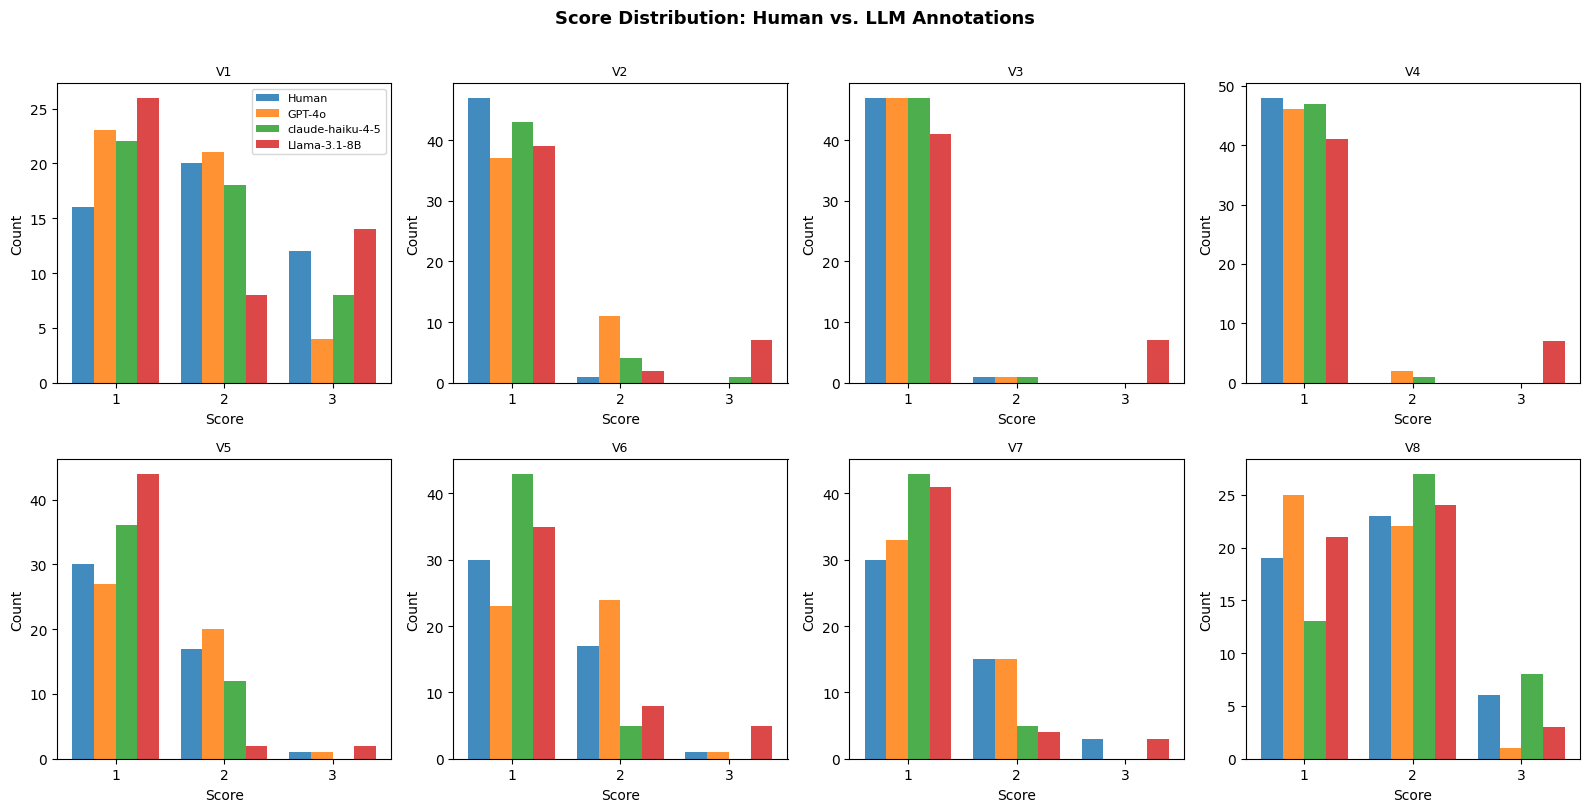

Saved: figure_score_distributions.png

Mean Absolute Deviation: Human vs. LLM (per variable)
Flagged if MAE >= 1.0
  Variable  GPT-4o                  claude-haiku-4-5        Llama-3.1-8B          
----------------------------------------------------------------------
  V1        MAE=0.40 STD=0.58      MAE=0.29 STD=0.54      MAE=0.33 STD=0.62    
  V2        MAE=0.21 STD=0.41      MAE=0.10 STD=0.37      MAE=0.31 STD=0.68    
  V3        MAE=0.04 STD=0.20      MAE=0.00 STD=0.00      MAE=0.27 STD=0.67    
  V4        MAE=0.04 STD=0.20      MAE=0.02 STD=0.14      MAE=0.29 STD=0.71    
  V5        MAE=0.31 STD=0.56      MAE=0.27 STD=0.50      MAE=0.35 STD=0.57    
  V6        MAE=0.35 STD=0.58      MAE=0.33 STD=0.50      MAE=0.48 STD=0.78    
  V7        MAE=0.29 STD=0.53      MAE=0.38 STD=0.55      MAE=0.44 STD=0.71    
  V8        MAE=0.48 STD=0.71      MAE=0.50 STD=0.77      MAE=0.56 STD=0.85    

Saved: csv/table_score_deviations.csv

Human–LLM Agreement (Pairwise): Cohen's Kappa + Spe

/var/folders/q8/tplwq65x58bf8st5czfxkmlw0000gn/T/ipykernel_16440/453064939.py:134: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(human_v, model_v)
/var/folders/q8/tplwq65x58bf8st5czfxkmlw0000gn/T/ipykernel_16440/453064939.py:134: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(human_v, model_v)
/var/folders/q8/tplwq65x58bf8st5czfxkmlw0000gn/T/ipykernel_16440/453064939.py:134: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(human_v, model_v)


In [6]:
# load and validate 
llm_all = pd.read_csv(LLM_ANNOTATION_FILE)
llm_all.columns = llm_all.columns.str.strip()

required_llm_cols = ["tweet_id", "llm_name_version"] + SCORE_COLS
missing = [c for c in required_llm_cols if c not in llm_all.columns]
if missing:
    raise ValueError(f"Missing columns in combined LLM file: {missing}")

# Split into per-model DataFrames keyed by display name
model_scores = {}
for model_info in MODELS.values():
    subset = llm_all[llm_all["llm_name_version"] == model_info["llm_name_version"]]
    subset = subset[["tweet_id"] + SCORE_COLS].dropna(subset=SCORE_COLS)
    subset = subset.set_index("tweet_id")
    model_scores[model_info["display_name"]] = subset
    print(f"Loaded {model_info['display_name']}: {len(subset)} tweets")

# align on common tweet_ids across all models + human re-annotation
# Use re-annotated 50 tweets as human baseline for human-LLM comparison
human_df = reannotated_df.copy()
human_df = human_df[SCORE_COLS].dropna()
human_scores = human_df  # already indexed by row_id from earlier

# Find common tweet_ids across human + all models
common_ids = set(human_scores.index)
for name, scores in model_scores.items():
    common_ids = common_ids.intersection(set(scores.index))
common_ids = list(common_ids)
print(f"\nTweets with complete annotations (human + all models): {len(common_ids)}")

human_aligned = human_scores.loc[common_ids]
model_aligned = {name: sc.loc[common_ids] for name, sc in model_scores.items()}

# 4. Score distribution comparison: Human vs. LLMs 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

all_annotators = {"Human": human_aligned, **model_aligned}
colors = [cm.tab10(i) for i in range(len(all_annotators))]
n = len(all_annotators)
width = 0.8 / n

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    for j, (name, scores) in enumerate(all_annotators.items()):
        counts = scores[col].value_counts().sort_index()
        x = np.array([1, 2, 3])
        y = np.array([counts.get(v, 0) for v in x])
        offset = (j - n / 2 + 0.5) * width
        ax.bar(x + offset, y, width=width,
               label=name, color=colors[j], alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3])
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Score Distribution: Human vs. LLM Annotations",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("csv/figure_score_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figure_score_distributions.png")

# Mean absolute deviation (human vs each LLM)
print("\n" + "=" * 70)
print("Mean Absolute Deviation: Human vs. LLM (per variable)")
print(f"Flagged if MAE >= 1.0")
print("=" * 70)
print(f"  {'Variable':<8}", end="")
for name in model_aligned:
    print(f"  {name:<22}", end="")
print()
print("-" * 70)

deviation_records = []
DEVIATION_THRESHOLD = 1.0

for col in SCORE_COLS:
    human_v = human_aligned[col].values
    print(f"  {col:<8}", end="")
    for name, scores in model_aligned.items():
        model_v = scores[col].values
        mae  = np.mean(np.abs(model_v - human_v))
        std  = np.std(model_v - human_v)
        flag = " ⚠️" if mae >= DEVIATION_THRESHOLD else ""
        print(f"  MAE={mae:.2f} STD={std:.2f}{flag:<4}", end="")
        deviation_records.append({
            "Variable":          col,
            "Model":             name,
            "Mean_Abs_Deviation": round(mae, 4),
            "Std_Deviation":     round(std, 4),
            "Flagged":           mae >= DEVIATION_THRESHOLD
        })
    print()

deviation_df = pd.DataFrame(deviation_records)
deviation_df.to_csv("csv/table_score_deviations.csv", index=False)
print("\nSaved: csv/table_score_deviations.csv")

# Human LLM agreement: Cohen's Kappa + Spearman rho + Krippendorff's alpha
print("\n" + "=" * 75)
print("Human–LLM Agreement (Pairwise): Cohen's Kappa + Spearman rho")
print("=" * 75)
print(f"  {'Variable':<40} {'rho':>7} {'p':>8} {'kappa':>7}")
print("-" * 75)

agreement_records = []

for model_name, model_sc in model_aligned.items():
    print(f"\n  ── {model_name} ──")
    for col in SCORE_COLS:
        human_v = human_aligned[col].values
        model_v = model_sc[col].values

        rho, p = spearmanr(human_v, model_v)
        kappa  = cohen_kappa_score(human_v, model_v, weights='linear')

        flag = " ⚠️" if kappa < 0.4 else ""
        print(f"  {col:<40} {rho:>7.3f} {p:>8.4f} {kappa:>7.3f}{flag}")
        agreement_records.append({
            "Model":        model_name,
            "Variable":     col,
            "Spearman_rho": round(rho, 4),
            "p_value":      round(p, 4),
            "Cohen_kappa":  round(kappa, 4),
        })

    # Total score
    human_total = human_aligned[SCORE_COLS].sum(axis=1).values
    model_total = model_sc[SCORE_COLS].sum(axis=1).values
    rho_total, p_total = spearmanr(human_total, model_total)
    kappa_total = cohen_kappa_score(
        human_total.astype(int), model_total.astype(int), weights='linear'
    )
    print(f"  {'TOTAL SCORE':<40} {rho_total:>7.3f} {p_total:>8.4f} {kappa_total:>7.3f}")
    print(f"  {'(Jia et al. 2024 benchmark: rho = .75)':<40}")

agreement_df = pd.DataFrame(agreement_records)
agreement_df.to_csv("csv/table_human_llm_agreement.csv", index=False)
print("\nSaved: csv/table_human_llm_agreement.csv")


Performance compared to 
1. eachother
2. original human annotations 
3. reannotated human annotations 

In [ ]:
# Multi-Annotator Reliability: Krippendorff's Alpha (human + 3 LLMs)
print("\n" + "=" * 75)
print("Multi-Annotator Reliability: Krippendorff's Alpha")
print("Human + all 3 LLMs simultaneously (ordinal)")
print("=" * 75)
print(f"  {'Variable':<10} {'alpha':>7}")
print("-" * 75)

multi_records = []

for col in SCORE_COLS:
    all_raters = np.array(
        [human_aligned[col].values] +
        [model_aligned[name][col].values for name in model_aligned],
        dtype=float
    )
    alpha = krippendorff.alpha(
        reliability_data=all_raters,
        level_of_measurement='ordinal'
    )
    flag = " ⚠️" if alpha < 0.6 else ""
    print(f"  {col:<10} {alpha:>7.3f}{flag}")
    multi_records.append({"Variable": col, "Krippendorff_alpha": round(alpha, 4)})

# Total score
all_totals = np.array(
    [human_aligned[SCORE_COLS].sum(axis=1).values] +
    [model_aligned[name][SCORE_COLS].sum(axis=1).values for name in model_aligned],
    dtype=float
)
alpha_total = krippendorff.alpha(
    reliability_data=all_totals,
    level_of_measurement='ordinal'
)
print(f"  {'TOTAL SCORE':<10} {alpha_total:>7.3f}")

multi_df = pd.DataFrame(multi_records)
multi_df.to_csv("csv/table_multi_annotator_alpha.csv", index=False)
print("\nSaved: csv/table_multi_annotator_alpha.csv")

# Inter LLM scores: Pairwise Krippendorff's alpha 
# full 300-tweet dataset
print("\n" + "=" * 55)
print("Inter-LLM Consistency: Pairwise Krippendorff's Alpha")
print("=" * 55)

# Use full model_scores (all 300 tweets, no human constraint)
common_ids_llm = list(set.intersection(*[set(df.index) for df in model_scores.values()]))
model_aligned_all = {name: df.loc[common_ids_llm] for name, df in model_scores.items()}
print(f"Tweets annotated by all LLMs: {len(common_ids_llm)}")

model_names    = list(model_aligned_all.keys())
inter_records  = []

for col in SCORE_COLS:
    print(f"\n  {col}")
    print(f"  {'Model A':<22} {'Model B':<22} {'alpha':>7}")
    print("  " + "-" * 55)

    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            name_a, name_b = model_names[i], model_names[j]
            v_a = model_aligned_all[name_a][col].values
            v_b = model_aligned_all[name_b][col].values
            alpha = krippendorff.alpha(
                reliability_data=np.array([v_a, v_b], dtype=float),
                level_of_measurement='ordinal'
            )
            print(f"  {name_a:<22} {name_b:<22} {alpha:>7.3f}")
            inter_records.append({
                "Variable":          col,
                "Model_A":           name_a,
                "Model_B":           name_b,
                "Krippendorff_alpha": round(alpha, 4)
            })

    # Multi-rater alpha across all three LLMs
    all_raters = np.array(
        [model_aligned_all[n][col].values for n in model_names],
        dtype=float
    )
    multi_alpha = krippendorff.alpha(
        reliability_data=all_raters,
        level_of_measurement='ordinal'
    )
    print(f"  {'Multi-rater (all LLMs)':<44} {multi_alpha:>7.3f}")

inter_df = pd.DataFrame(inter_records)
inter_df.to_csv("csv/table_inter_llm_consistency.csv", index=False)
print("\nSaved: csv/table_inter_llm_consistency.csv")

# Study 2

## Phase 2: Ideological Skew Analysis

In [10]:
def load_framing_results(base_path: str = "csv") -> pd.DataFrame:
    """Load all framing CSVs into a single combined DataFrame."""
    dfs = []
    for model_info in MODELS.values():
        model_name = model_info["display_name"]
        for condition in FRAMING_CONDITIONS:
            path = FRAMING_FILE_PATTERN.format(model=model_name, condition=condition)
            if os.path.exists(path):
                df = pd.read_csv(path)
                df["framing_condition"] = condition
                df["model"] = model_name
                dfs.append(df)
            else:
                print(f"Warning: {path} not found, skipping.")
    combined = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(combined)} rows across "
          f"{combined['model'].nunique()} models and "
          f"{combined['framing_condition'].nunique()} conditions.")
    return combined

framing_df = load_framing_results()

Loaded 450 rows across 3 models and 5 conditions.


In [12]:
from scipy.stats import mannwhitneyu

#  Table A: Mean score delta vs neutral + Mann-Whitney significance 

print("\n" + "=" * 75)
print("Table A — Mean Score Delta vs Neutral: Direction & Magnitude")
print("Mann-Whitney U (two-sided) · *** p<.001 · ** p<.01 · * p<.05 · ns")
print("=" * 75)

NON_NEUTRAL   = [c for c in FRAMING_CONDITIONS if c != "Neutral"]
delta_records = []

for model_info in MODELS.values():
    model_name = model_info["display_name"]
    model_df   = framing_df[framing_df["model"] == model_name]

    if "Neutral" not in model_df["framing_condition"].values:
        print(f"\n  Warning: Neutral condition missing for {model_name}, skipping.")
        continue

    neutral_df = model_df[model_df["framing_condition"] == "Neutral"]

    print(f"\n  ── {model_name} ──")
    print(f"  {'Variable':<6} {'Condition':<15} {'Neutral':>8} {'Cond.':>8} "
          f"{'Delta':>7} {'p':>8} {'Sig':>4}")
    print("  " + "-" * 60)

    for condition in NON_NEUTRAL:
        condition_df = model_df[model_df["framing_condition"] == condition]
        if condition_df.empty:
            print(f"  Warning: condition '{condition}' missing for {model_name}, skipping.")
            continue

        for col in SCORE_COLS:
            neutral_v   = neutral_df[col].dropna()
            condition_v = condition_df[col].dropna()

            delta = round(condition_v.mean() - neutral_v.mean(), 3)

            # Mann-Whitney U — non-parametric, appropriate for ordinal 1–3 scale
            if neutral_v.nunique() > 1 or condition_v.nunique() > 1:
                stat, p = mannwhitneyu(neutral_v, condition_v, alternative="two-sided")
            else:
                stat, p = float("nan"), float("nan")

            sig  = ("***" if p < 0.001 else "**" if p < 0.01
                    else "*" if p < 0.05 else "ns")
            flag = " ⚠️" if abs(delta) >= 0.2 else ""

            print(f"  {col:<6} {condition:<15} {neutral_v.mean():>8.3f} "
                  f"{condition_v.mean():>8.3f} {delta:>+7.3f} "
                  f"{p:>8.4f} {sig:>4}{flag}")

            delta_records.append({
                "Model":          model_name,
                "Condition":      condition,
                "Variable":       col,
                "Neutral_mean":   round(neutral_v.mean(), 4),
                "Condition_mean": round(condition_v.mean(), 4),
                "Delta":          delta,
                "MW_stat":        round(stat, 4) if not np.isnan(stat) else "",
                "p_value":        round(p, 4)    if not np.isnan(p)    else "",
                "Significance":   sig,
                "Flagged":        abs(delta) >= 0.2,
            })

delta_df = pd.DataFrame(delta_records)
delta_df.to_csv("csv/table_framing_deltas.csv", index=False)
print("\nSaved: csv/table_framing_deltas.csv")


Table A — Mean Score Delta vs Neutral: Direction & Magnitude
Mann-Whitney U (two-sided) · *** p<.001 · ** p<.01 · * p<.05 · ns

  ── GPT-4o ──
  Variable Condition        Neutral    Cond.   Delta        p  Sig
  ------------------------------------------------------------
  V1     Conservative       1.667    1.633  -0.033   0.8316   ns
  V2     Conservative       1.200    1.267  +0.067   0.5517   ns
  V3     Conservative       1.033    1.000  -0.033   0.3337   ns
  V4     Conservative       1.100    1.033  -0.067   0.3128   ns
  V5     Conservative       1.533    1.467  -0.067   0.7155   ns
  V6     Conservative       1.467    1.500  +0.033   0.7086   ns
  V7     Conservative       1.333    1.333  +0.000   1.0000   ns
  V8     Conservative       1.500    1.433  -0.067   0.6138   ns
  V1     Liberal            1.667    1.633  -0.033   0.8316   ns
  V2     Liberal            1.200    1.333  +0.133   0.2508   ns
  V3     Liberal            1.033    1.033  +0.000   1.0000   ns
  V4     Li

In [14]:
print("\n" + "=" * 75)
print("Table B — Distributional Skew: Proportion at Each Score Point")
print("Positive delta = inflation vs neutral · Negative = compression")
print("=" * 75)

skew_records = []

for model_info in MODELS.values():
    model_name = model_info["display_name"]
    model_df   = framing_df[framing_df["model"] == model_name]

    if "Neutral" not in model_df["framing_condition"].values:
        continue

    neutral_df = model_df[model_df["framing_condition"] == "Neutral"]

    print(f"\n  ── {model_name} ──")

    for col in SCORE_COLS:
        neutral_scores = neutral_df[col].dropna()
        neutral_props  = {s: (neutral_scores == s).mean() for s in [1, 2, 3]}

        for condition in FRAMING_CONDITIONS:
            condition_df = model_df[model_df["framing_condition"] == condition]
            if condition_df.empty:
                continue

            scores = condition_df[col].dropna()
            total  = len(scores)

            for score_val in [1, 2, 3]:
                prop       = (scores == score_val).sum() / total if total > 0 else float("nan")
                prop_delta = round(prop - neutral_props[score_val], 4)

                skew_records.append({
                    "Model":        model_name,
                    "Condition":    condition,
                    "Variable":     col,
                    "Score":        score_val,
                    "Proportion":   round(prop, 4),
                    "Count":        int((scores == score_val).sum()),
                    "N":            total,
                    "Neutral_prop": round(neutral_props[score_val], 4),
                    "Prop_delta":   prop_delta,
                })

    # Print score-3 inflation summary
    model_skew = pd.DataFrame(skew_records)
    model_skew = model_skew[
        (model_skew["Model"] == model_name) &
        (model_skew["Score"] == 3) &
        (model_skew["Condition"] != "Neutral")
    ]

    if not model_skew.empty:
        pivot = model_skew.pivot_table(
            index="Variable", columns="Condition", values="Prop_delta"
        ).reindex(columns=NON_NEUTRAL).round(3)

        print(f"\n  Score-3 proportion delta vs Neutral (positive = high-end inflation):")
        print(f"  {'Variable':<8}", end="")
        for c in NON_NEUTRAL:
            print(f"  {c:<14}", end="")
        print()
        print("  " + "-" * (8 + 16 * len(NON_NEUTRAL)))

        for var in SCORE_COLS:
            if var in pivot.index:
                print(f"  {var:<8}", end="")
                for c in NON_NEUTRAL:
                    val  = pivot.loc[var, c] if c in pivot.columns else float("nan")
                    flag = " ⚠️" if abs(val) >= 0.15 else ""
                    print(f"  {val:>+8.3f}{flag:<6}", end="")
                print()

skew_df = pd.DataFrame(skew_records)
skew_df.to_csv("csv/table_framing_skew.csv", index=False)
print("\nSaved: csv/table_framing_skew.csv")


Table B — Distributional Skew: Proportion at Each Score Point
Positive delta = inflation vs neutral · Negative = compression

  ── GPT-4o ──

  Score-3 proportion delta vs Neutral (positive = high-end inflation):
  Variable  Conservative    Liberal         Democrat        Republican    
  ------------------------------------------------------------------------
  V1          +0.000          +0.000          +0.000          +0.000      
  V2          +0.000          +0.000          +0.000          +0.000      
  V3          +0.000          +0.000          +0.000          +0.000      
  V4          +0.000          +0.000          +0.000          +0.000      
  V5          -0.033          +0.000          +0.000          +0.033      
  V6          -0.033          +0.000          +0.000          +0.033      
  V7          +0.000          +0.000          +0.000          +0.000      
  V8          +0.000          +0.000          +0.000          +0.000      

  ── claude-haiku-4-5 ──

  Score-3

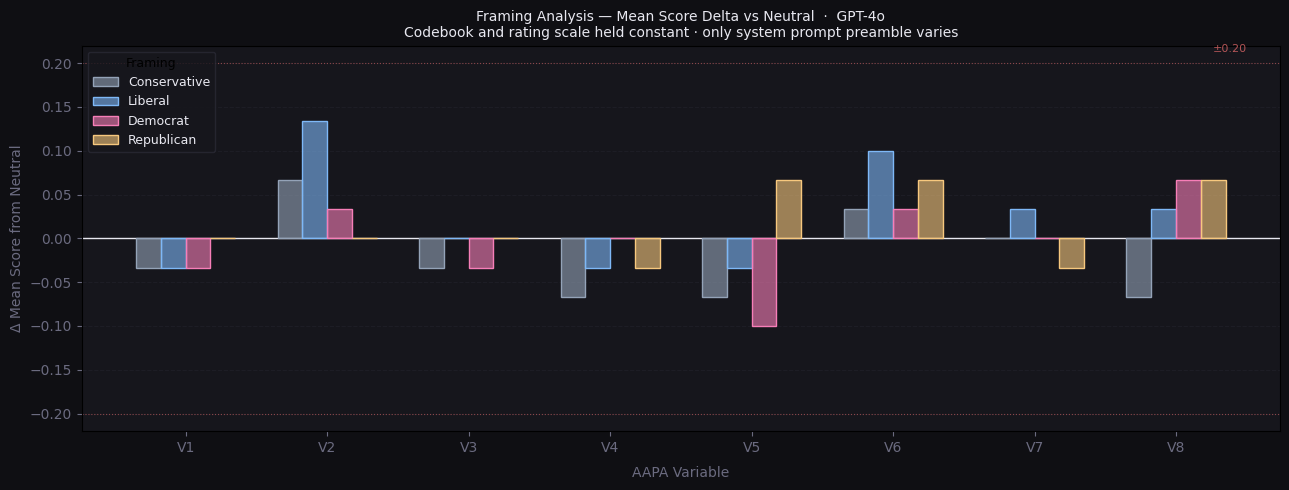

Saved: csv/framing_analysis/fig_delta_GPT-4o.png


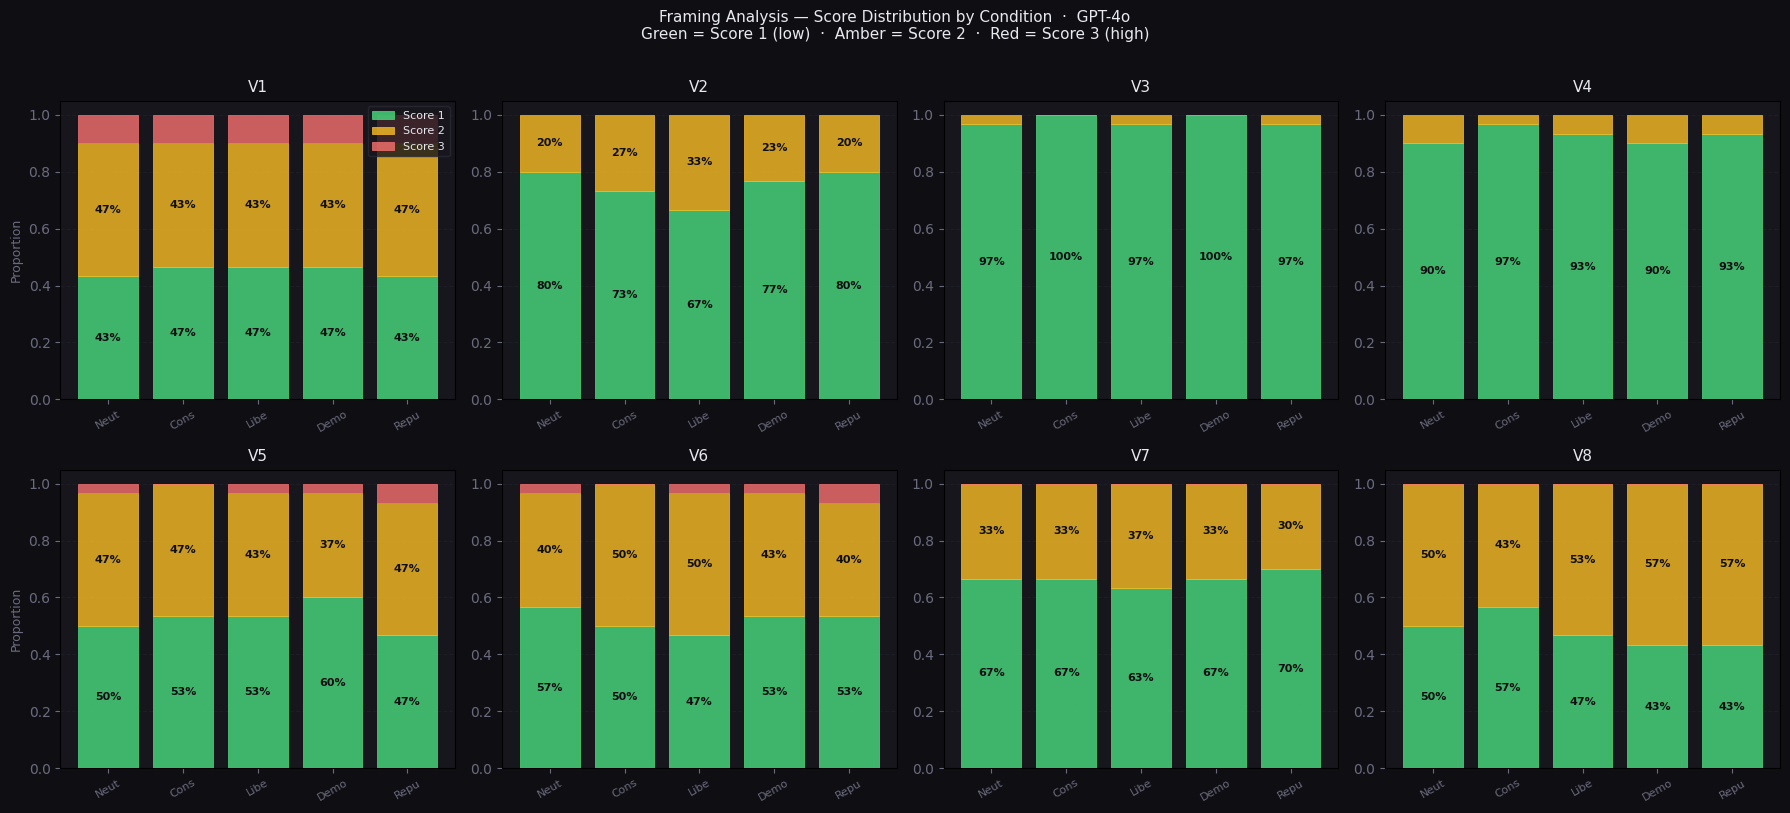

Saved: csv/framing_analysis/fig_skew_GPT-4o.png


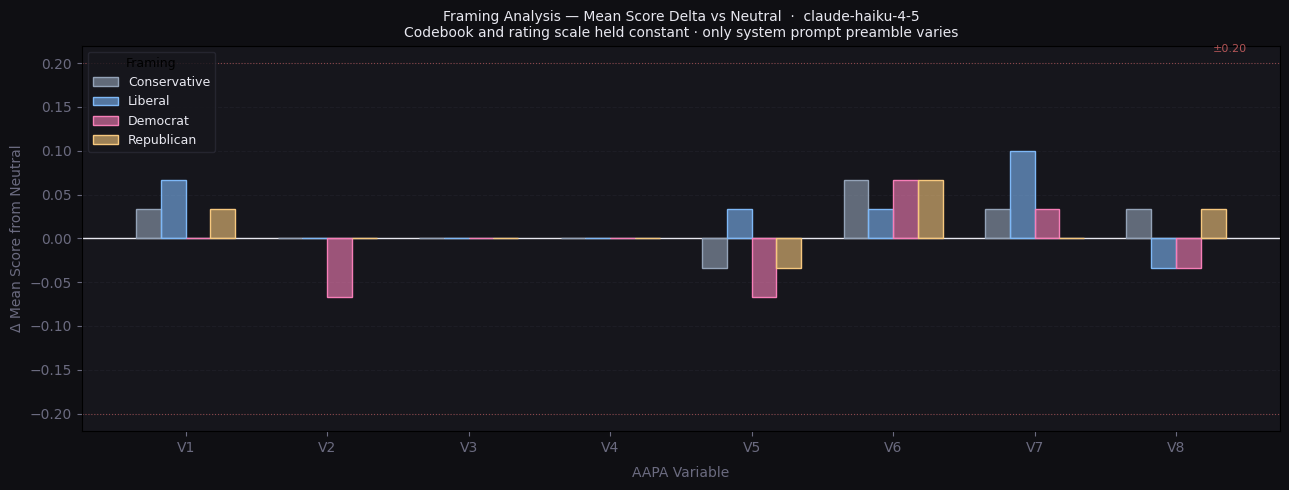

Saved: csv/framing_analysis/fig_delta_claude-haiku-4-5.png


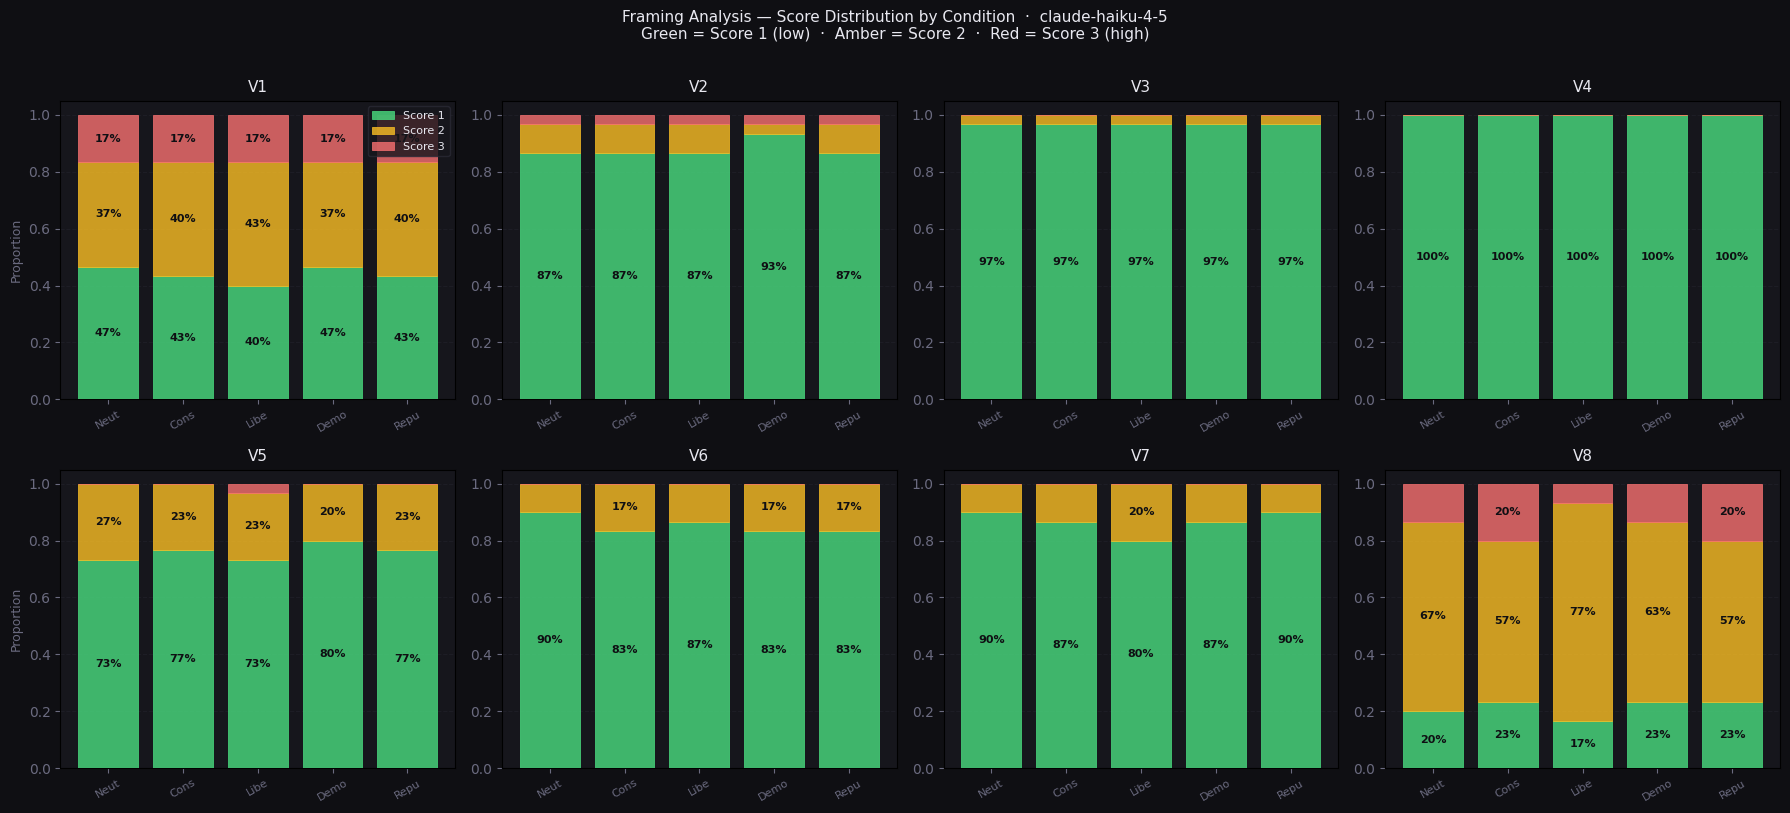

Saved: csv/framing_analysis/fig_skew_claude-haiku-4-5.png


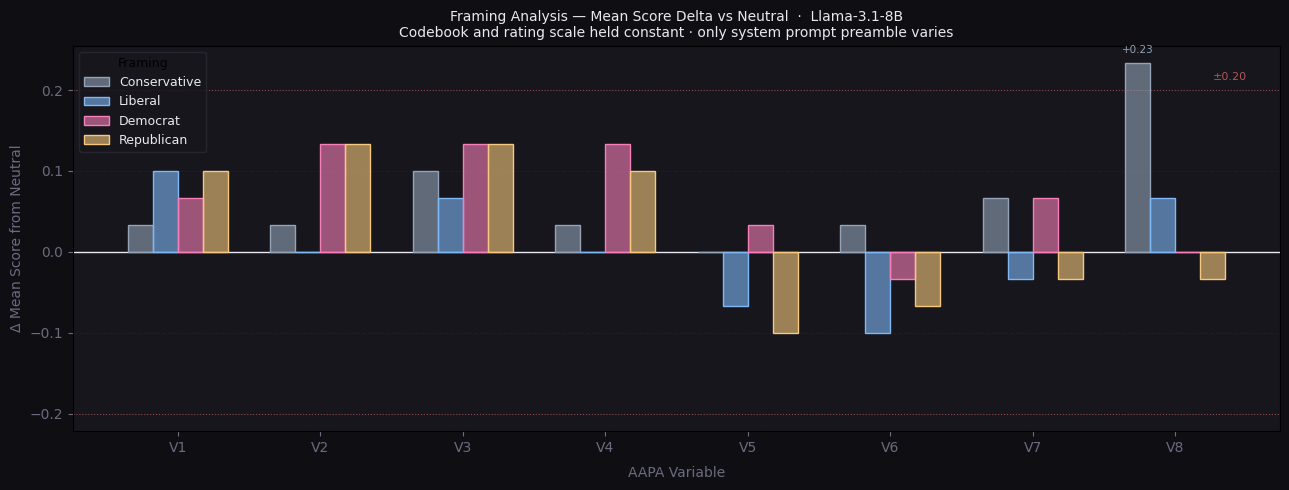

Saved: csv/framing_analysis/fig_delta_Llama-3.1-8B.png


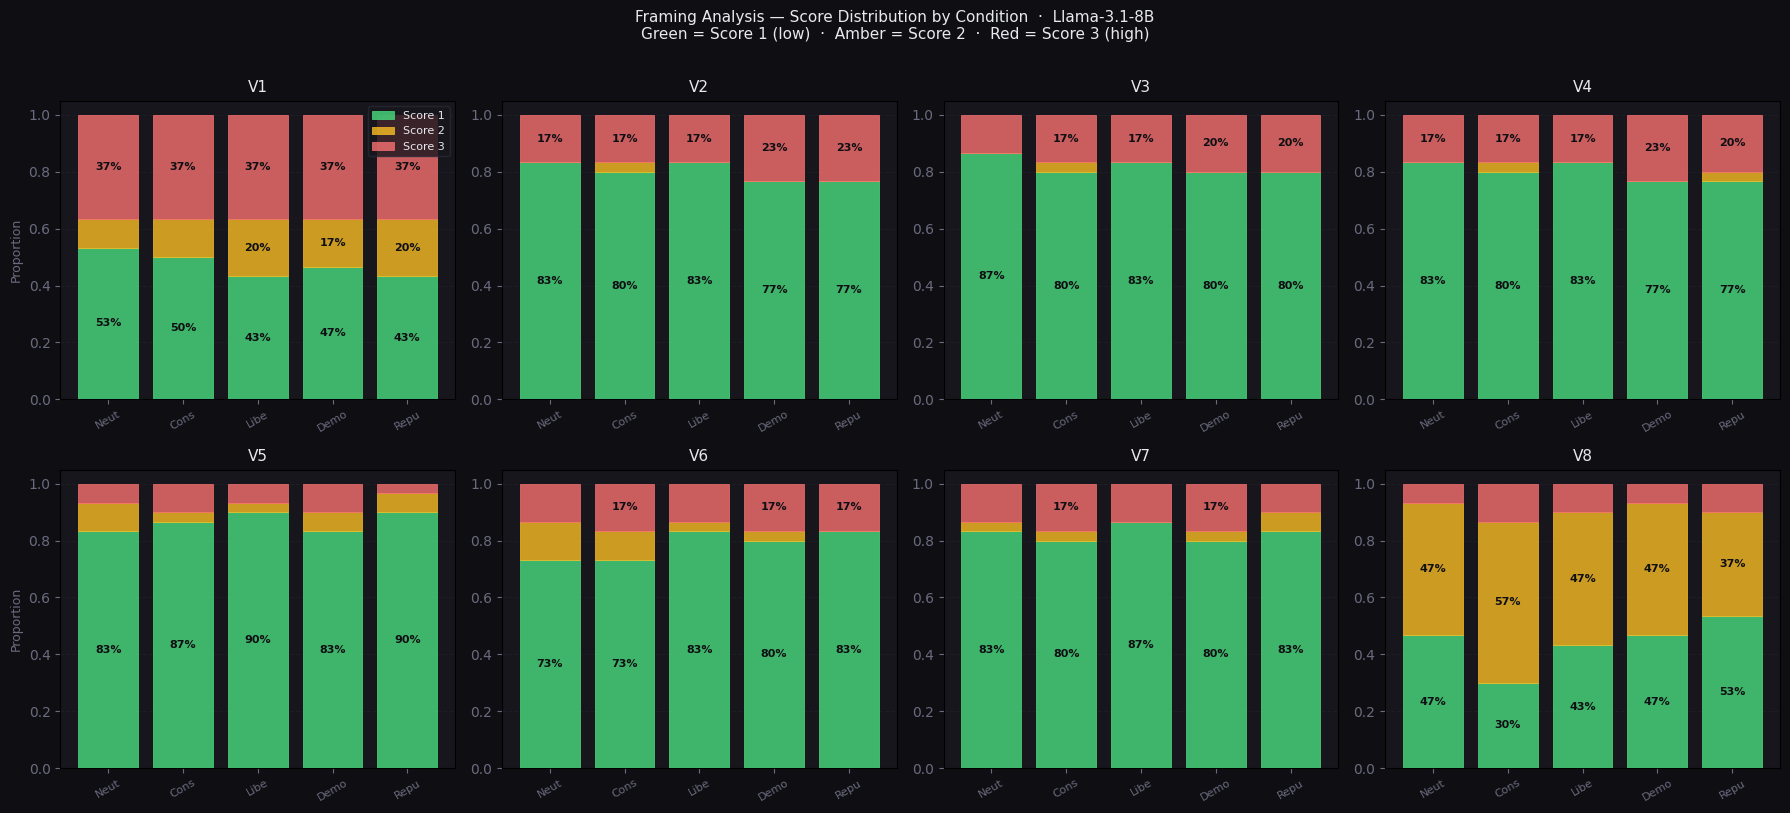

Saved: csv/framing_analysis/fig_skew_Llama-3.1-8B.png


In [15]:
# Plots 

FRAMING_COLORS = {
    "Conservative": "#94a3b8",
    "Liberal":      "#7eb8f7",
    "Democrat":     "#f77eb8",
    "Republican":   "#f7c87e",
}
SCORE_COLORS = {1: "#4ade80", 2: "#fbbf24", 3: "#f87171"}

os.makedirs("csv/framing_analysis", exist_ok=True)

for model_info in MODELS.values():
    model_name = model_info["display_name"]
    model_df   = framing_df[framing_df["model"] == model_name]

    if "Neutral" not in model_df["framing_condition"].values:
        continue

    neutral_df    = model_df[model_df["framing_condition"] == "Neutral"]
    neutral_means = neutral_df[SCORE_COLS].mean()

    # Plot A: Mean delta bar chart 

    deltas = {}
    for condition in NON_NEUTRAL:
        cdf = model_df[model_df["framing_condition"] == condition]
        if not cdf.empty:
            deltas[condition] = (cdf[SCORE_COLS].mean() - neutral_means).values

    if deltas:
        x     = np.arange(len(SCORE_COLS))
        n     = len(deltas)
        width = 0.7 / n

        fig, ax = plt.subplots(figsize=(13, 5))
        fig.patch.set_facecolor("#0f0f13")
        ax.set_facecolor("#16161c")

        for ci, (condition, vals) in enumerate(deltas.items()):
            color  = FRAMING_COLORS.get(condition, "#a78bfa")
            offset = (ci - n / 2 + 0.5) * width
            bars   = ax.bar(x + offset, vals, width=width,
                            color=color + "99", edgecolor=color,
                            linewidth=1, label=condition, zorder=3)
            for bar, val in zip(bars, vals):
                if abs(val) > 0.15:
                    ax.text(bar.get_x() + bar.get_width() / 2,
                            val + (0.01 if val >= 0 else -0.03),
                            f"{val:+.2f}",
                            ha="center", va="bottom" if val >= 0 else "top",
                            color=color, fontsize=7.5)

        ax.axhline(0,    color="#e8e8f0", linewidth=1)
        ax.axhline( 0.2, color="#f87171", linestyle=":", linewidth=0.8, alpha=0.5)
        ax.axhline(-0.2, color="#f87171", linestyle=":", linewidth=0.8, alpha=0.5)
        ax.text(len(SCORE_COLS) - 0.5, 0.21, "±0.20",
                color="#f87171", fontsize=8, va="bottom", ha="right", alpha=0.7)

        ax.set_xticks(x)
        ax.set_xticklabels(SCORE_COLS, color="#e8e8f0")
        ax.set_xlabel("AAPA Variable", color="#6b6b80", labelpad=8)
        ax.set_ylabel("Δ Mean Score from Neutral", color="#6b6b80")
        ax.set_title(
            f"Framing Analysis — Mean Score Delta vs Neutral  ·  {model_name}\n"
            "Codebook and rating scale held constant · only system prompt preamble varies",
            color="#e8e8f0", fontsize=10
        )
        ax.legend(fontsize=9, facecolor="#16161c", edgecolor="#2a2a35",
                  labelcolor="#e8e8f0", title="Framing", title_fontsize=9)
        ax.grid(axis="y", color="#2a2a35", linestyle="--", alpha=0.4, zorder=0)
        ax.tick_params(colors="#6b6b80")
        plt.tight_layout()
        path_a = f"csv/framing_analysis/fig_delta_{model_name}.png"
        plt.savefig(path_a, dpi=150, bbox_inches="tight", facecolor="#0f0f13")
        plt.show()
        print(f"Saved: {path_a}")

    # ── Plot B: Stacked score distributions per variable per condition ────────

    conditions_available = [c for c in FRAMING_CONDITIONS
                            if not model_df[model_df["framing_condition"] == c].empty]
    n_cond = len(conditions_available)

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.patch.set_facecolor("#0f0f13")
    axes = axes.flatten()

    for vi, var in enumerate(SCORE_COLS):
        ax = axes[vi]
        ax.set_facecolor("#16161c")

        prop_data = []
        for cond in conditions_available:
            cdf    = model_df[model_df["framing_condition"] == cond]
            scores = cdf[var].dropna()
            total  = len(scores)
            prop_data.append({s: (scores == s).sum() / total for s in [1, 2, 3]})

        x_pos  = np.arange(n_cond)
        bottom = np.zeros(n_cond)

        for score_val in [1, 2, 3]:
            vals = np.array([p[score_val] for p in prop_data])
            color = SCORE_COLORS[score_val]
            ax.bar(x_pos, vals, bottom=bottom,
                   color=color + "cc", edgecolor=color,
                   linewidth=0.5,
                   label=f"Score {score_val}" if vi == 0 else "",
                   zorder=3)
            for xi, (val, bot) in enumerate(zip(vals, bottom)):
                if val > 0.15:
                    ax.text(xi, bot + val / 2, f"{val:.0%}",
                            ha="center", va="center",
                            color="#0f0f13", fontsize=8, fontweight="bold")
            bottom += vals

        ax.set_title(var, color="#e8e8f0", fontsize=11)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([c[:4] for c in conditions_available],
                           color="#6b6b80", fontsize=8, rotation=30)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Proportion" if vi % 4 == 0 else "", color="#6b6b80", fontsize=9)
        ax.grid(axis="y", color="#2a2a35", linestyle="--", alpha=0.4, zorder=0)
        ax.tick_params(colors="#6b6b80")

        if vi == 0:
            ax.legend(fontsize=8, facecolor="#16161c", edgecolor="#2a2a35",
                      labelcolor="#e8e8f0", loc="upper right")

    fig.suptitle(
        f"Framing Analysis — Score Distribution by Condition  ·  {model_name}\n"
        "Green = Score 1 (low)  ·  Amber = Score 2  ·  Red = Score 3 (high)",
        color="#e8e8f0", fontsize=11, y=1.01
    )
    plt.tight_layout()
    path_b = f"csv/framing_analysis/fig_skew_{model_name}.png"
    plt.savefig(path_b, dpi=150, bbox_inches="tight", facecolor="#0f0f13")
    plt.show()
    print(f"Saved: {path_b}")


 
 
 # 3: {
    #     "llm_name_version": "deepseek-chat",
    #     "provider":         "deepseek",
    #     "display_name":     "DeepSeek-V3",
    #     "rationale":        "Cost-efficient frontier model with strong instruction-following"
    # },
    #  4: {
    #     "llm_name_version": "gpt-4o-mini",
    #     "provider":         "4o-mini",
    #     "display_name":     "GPT-4o-mini",
    #     "rationale":        "Comparison; OpenAI's smaller model, much weaker than GPT-4o"
    # },
    # 5: {
    #     "llm_name_version": "meta-llama/Llama-3.3-70B-Instruct-Turbo",
    #     "provider":         "llama70b",
    #     "display_name":     "Llama-3.3-70B",
    #     "rationale":        "Open-source frontier model via Together AI"
    # },
    #  6: {
    #     "llm_name_version": "mistralai/Mistral-7B-Instruct-v0.3",
    #     "provider":         "mistral7b",
    #     "display_name":     "Mistral-7B",
    #     "rationale":        "Small open-weight baseline; standard benchmark in NLP annotation studies"
    # },